In [3]:
# importing packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## **Loading, Understanding the data**

In [4]:
df = pd.read_csv("/kaggle/input/datasets/juhibhojani/house-price/house_prices.csv")
df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [5]:
df.shape

(187531, 21)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  object 
 2   Description        184508 non-null  object 
 3   Amount(in rupees)  187531 non-null  object 
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  object 
 6   Carpet Area        106858 non-null  object 
 7   Status             186916 non-null  object 
 8   Floor              180454 non-null  object 
 9   Transaction        187448 non-null  object 
 10  Furnishing         184634 non-null  object 
 11  facing             117298 non-null  object 
 12  overlooking        106095 non-null  object 
 13  Society            77853 non-null   object 
 14  Bathroom           186703 non-null  object 
 15  Balcony            138596 non-null  object 
 16  Ca

In [7]:
df.isnull().sum()

Index                     0
Title                     0
Description            3023
Amount(in rupees)         0
Price (in rupees)     17665
location                  0
Carpet Area           80673
Status                  615
Floor                  7077
Transaction              83
Furnishing             2897
facing                70233
overlooking           81436
Society              109678
Bathroom                828
Balcony               48935
Car Parking          103357
Ownership             65517
Super Area           107685
Dimensions           187531
Plot Area            187531
dtype: int64

In [8]:
print("num of duplicate rows:", df.duplicated().sum())

num of duplicate rows: 0


In [9]:
# seperate the numerical and categorical columns
df_cat = df.select_dtypes(['object'])
df_num = df.select_dtypes(['int64', 'float64'])

In [10]:
df_cat.describe()

,Title,Description,Amount(in rupees),location,Carpet Area,Status,Floor,Transaction,Furnishing,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area
count,187531,184508,187531,187531,106858,186916,180454,187448,184634,117298,106095,77853,186703,138596,84174,122014,79846
unique,32446,65634,1561,81,2758,1,947,4,3,8,19,10376,11,11,229,4,2976
top,2 BHK Ready to Occupy Flat for sale in Divyasr...,Multistorey apartment is available for sale. I...,Call for Price,new-delhi,1000 sqft,Ready to Move,2 out of 4,Resale,Semi-Furnished,East,Main Road,Hamdam Apartment,2,2,1 Covered,Freehold,1100 sqft
freq,2106,2732,9684,27599,5285,186916,12433,144172,88318,54741,32193,1648,93007,51809,38754,112229,2599


In [11]:
df_num.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])

,Index,Price (in rupees),Dimensions,Plot Area
count,187531.000000,1.698660e+05,0.0,0.0
mean,93765.000000,7.583772e+03,NaN,NaN
std,54135.681003,2.724171e+04,NaN,NaN
min,0.000000,0.000000e+00,NaN,NaN
10%,18753.000000,3.434000e+03,NaN,NaN
25%,46882.500000,4.297000e+03,NaN,NaN
50%,93765.000000,6.034000e+03,NaN,NaN
75%,140647.500000,9.450000e+03,NaN,NaN
90%,168777.000000,1.271400e+04,NaN,NaN
max,187530.000000,6.700000e+06,NaN,NaN


## **Data Preprocessing**

### **Renaming Columns**

In [12]:
df.rename(columns={
    'index': 'Index',
    'Amount(in rupees)': 'Amount',
    'Price (in rupees)': 'Price',
    'location': 'Location',
    'facing': 'Facing',
    'overlooking': 'Overlooking'
}, inplace=True)

df.rename(columns={col: col.replace(' ', '') for col in df.columns}, inplace=True)
df.head(2)

,Index,Title,Description,Amount,Price,Location,CarpetArea,Status,Floor,Transaction,...,Facing,Overlooking,Society,Bathroom,Balcony,CarParking,Ownership,SuperArea,Dimensions,PlotArea
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN


### **Handling Missing Data**

In [13]:
# droping non-essential columns
df.drop(['Index', 'Title', 'Description', 'Price', 'Society', 'Dimensions'], axis=1, inplace=True)

In [14]:
# check number of null values
df.isnull().sum().sort_values(ascending=False)

PlotArea       187531
SuperArea      107685
CarParking     103357
Overlooking     81436
CarpetArea      80673
Facing          70233
Ownership       65517
Balcony         48935
Floor            7077
Furnishing       2897
Bathroom          828
Status            615
Transaction        83
Amount              0
Location            0
dtype: int64

In [15]:
# drop null values from CarpetArea column
df.dropna(subset=['CarpetArea'], inplace=True)
df.shape

(106858, 15)

In [16]:
# drop columns PlotArea and SuperArea
df.drop(['PlotArea', 'SuperArea'], axis=1, inplace=True)

In [17]:
# fill null values in other columns
df['Bathroom'] = df['Bathroom'].fillna('0')
df['Balcony'] = df['Balcony'].fillna('0')
df['CarParking'] = df['CarParking'].fillna('0')

df['Overlooking'] = df['Overlooking'].fillna('Not Available')

df['Furnishing'] = df['Furnishing'].fillna(df['Furnishing'].mode()[0])
df['Status'] = df['Status'].fillna(df['Status'].mode()[0])
df['Transaction'] = df['Transaction'].fillna(df['Transaction'].mode()[0])

df['Floor'] = df['Floor'].fillna('0 out of 0')

df['Facing'] = df['Facing'].fillna('No data')
df['Ownership'] = df['Ownership'].fillna('No data')

In [18]:
df.reset_index(inplace=True)
df.drop('index', axis=1, inplace=True)

In [19]:
df.isnull().sum().sort_values(ascending=False)

Amount         0
Location       0
CarpetArea     0
Status         0
Floor          0
Transaction    0
Furnishing     0
Facing         0
Overlooking    0
Bathroom       0
Balcony        0
CarParking     0
Ownership      0
dtype: int64

### **Feature Engineering**

In [20]:
df.dtypes

Amount         object
Location       object
CarpetArea     object
Status         object
Floor          object
Transaction    object
Furnishing     object
Facing         object
Overlooking    object
Bathroom       object
Balcony        object
CarParking     object
Ownership      object
dtype: object

In [21]:
# removing certain records
df = df[df['Amount'] != 'Call for Price']
df = df[df['Floor'].str.count(' ') == 3]

df.reset_index(inplace=True)
df.drop('index', axis=1, inplace=True)

In [22]:
# handling Location column
df['Location'] = (df['Location'].str.replace('-', ' ')).str.title()

In [23]:
# handling Floor
df['Floor'] = df['Floor'].apply(lambda x: x.replace('Ground', '0').replace('Upper Basement', '-1').replace('Lower Basement', '-2').replace(' 0', ' 1'))

floor_splitted = df['Floor'].str.split(' ', expand=True)
house_floor = floor_splitted[0].astype(np.int64)
total_floors = floor_splitted[3].astype(np.int64)

df['Floor'] = house_floor / total_floors
df['TotalFloors'] = pd.Series(total_floors)

In [24]:
# handling Bathroom and Balcony
df['Bathroom'] = df['Bathroom'].replace('> 10', '11')
df['Balcony'] = df['Balcony'].replace('> 10', '11')

df['Bathroom'] = df['Bathroom'].astype(np.int64)
df['Balcony'] = df['Balcony'].astype(np.int64)

In [25]:
# handling CarParking
df['CarParking'] = df['CarParking'].str.split(' ', expand=True)[0].astype(np.int64)

In [26]:
# handling CarpetArea
df['CarpetArea'] = df['CarpetArea'].str.split(' ', expand=True)[0].astype(np.float64)

In [27]:
# handling Amount
amount_split = df['Amount'].str.split(' ', expand=True)
amount_lakhs = amount_split[0][amount_split[1] == 'Lac'].astype(np.float64)
amount_crores = amount_split[0][amount_split[1] == 'Cr'].astype(np.float64)

amount_temp = pd.Series(np.ones(df.shape[0], dtype=np.float64))
amount_temp.iloc[df[df['Amount'].str.endswith(' Lac ')].index] = amount_lakhs / 100
amount_temp.iloc[df[df['Amount'].str.endswith(' Cr ')].index] = amount_crores

df['Amount'] = amount_temp

In [28]:
# handling Overlooking
overlooking_dummies = df['Overlooking'].str.get_dummies(sep=', ')
overlooking_dummies = overlooking_dummies.add_prefix('Overlooking_')

overlooking_dummies.rename(columns={
    'Overlooking_Garden/Park': 'Overlooking_GardenPark',
    'Overlooking_Main Road': 'Overlooking_MainRoad',
    'Overlooking_Not Available': 'Overlooking_NotAvailable',
    'Overlooking_Pool': 'Overlooking_Pool'
}, inplace=True)

df = pd.concat([df, overlooking_dummies], axis=1)
df.drop('Overlooking', axis=1, inplace=True)

In [29]:
df = df.reindex(columns=['Location', 'Status', 'Transaction', 'Ownership', 'Furnishing', 'Facing', 'Overlooking_GardenPark', 'Overlooking_MainRoad', 'Overlooking_Pool', 'Overlooking_NotAvailable', 'Floor', 'TotalFloors', 'Bathroom', 'Balcony', 'CarParking', 'CarpetArea', 'Amount'])

In [30]:
df.dtypes

Location                     object
Status                       object
Transaction                  object
Ownership                    object
Furnishing                   object
Facing                       object
Overlooking_GardenPark        int64
Overlooking_MainRoad          int64
Overlooking_Pool              int64
Overlooking_NotAvailable      int64
Floor                       float64
TotalFloors                   int64
Bathroom                      int64
Balcony                       int64
CarParking                    int64
CarpetArea                  float64
Amount                      float64
dtype: object

### **Handling Outliers**

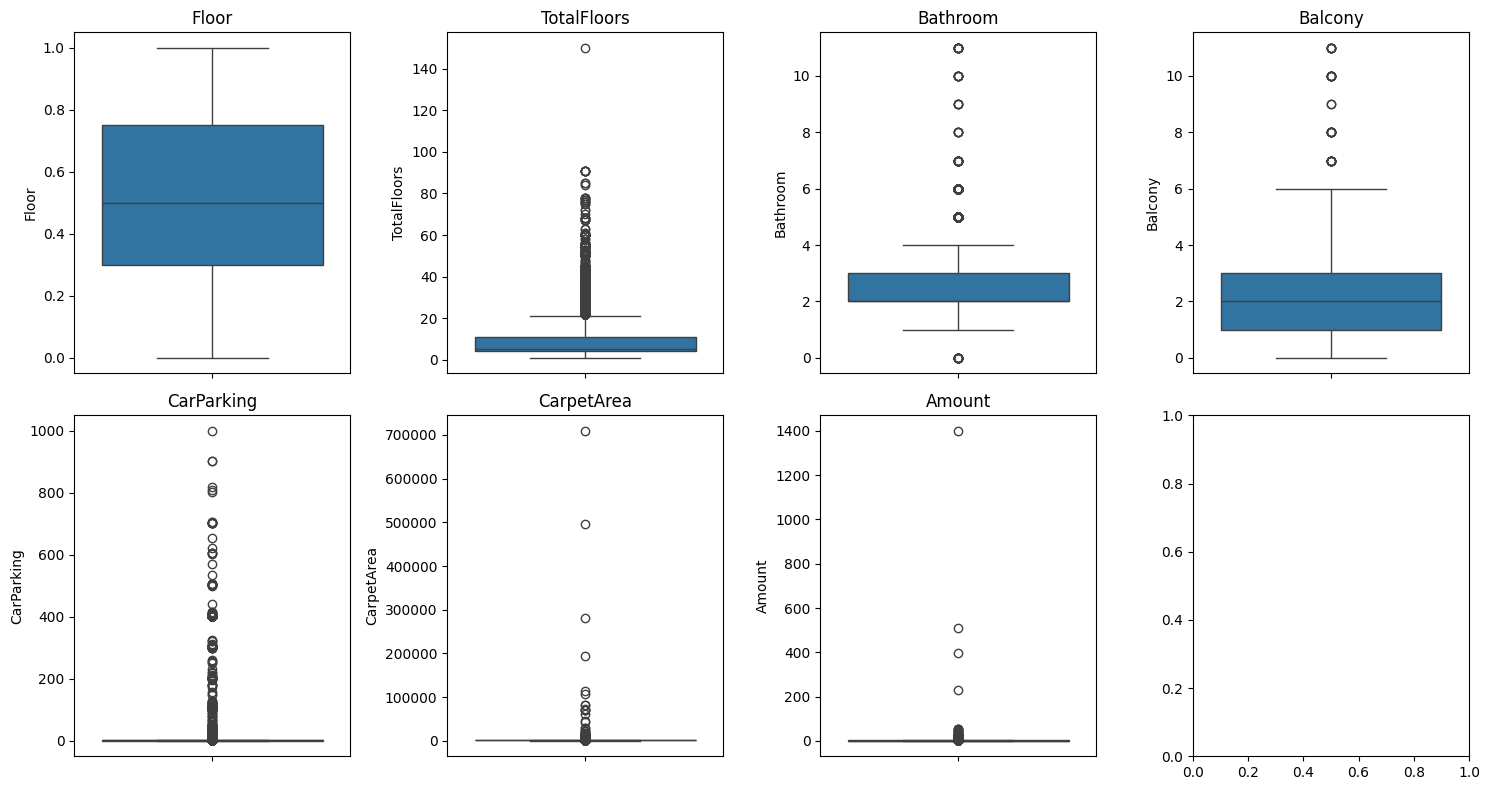

In [31]:
# check for outliers using boxplot
num_cols = ['Floor', 'TotalFloors', 'Bathroom', 'Balcony', 'CarParking', 'CarpetArea', 'Amount']
fig, ax = plt.subplots(2, 4, figsize=(15,8))

for i, col in enumerate(num_cols, start=1):
    plt.subplot(2, 4, i)
    sns.boxplot(df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [32]:
# handling CarParking using capping
df = df[df['CarParking'] <= 5]
num_cols.remove('CarParking')

In [33]:
# removing outliers using IQR
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    upper_limit = Q3 + 1.5 * IQR
    lower_limit = Q1 - 1.5 * IQR
    df = df[(df[col] >= lower_limit) & (df[col] <= upper_limit)]

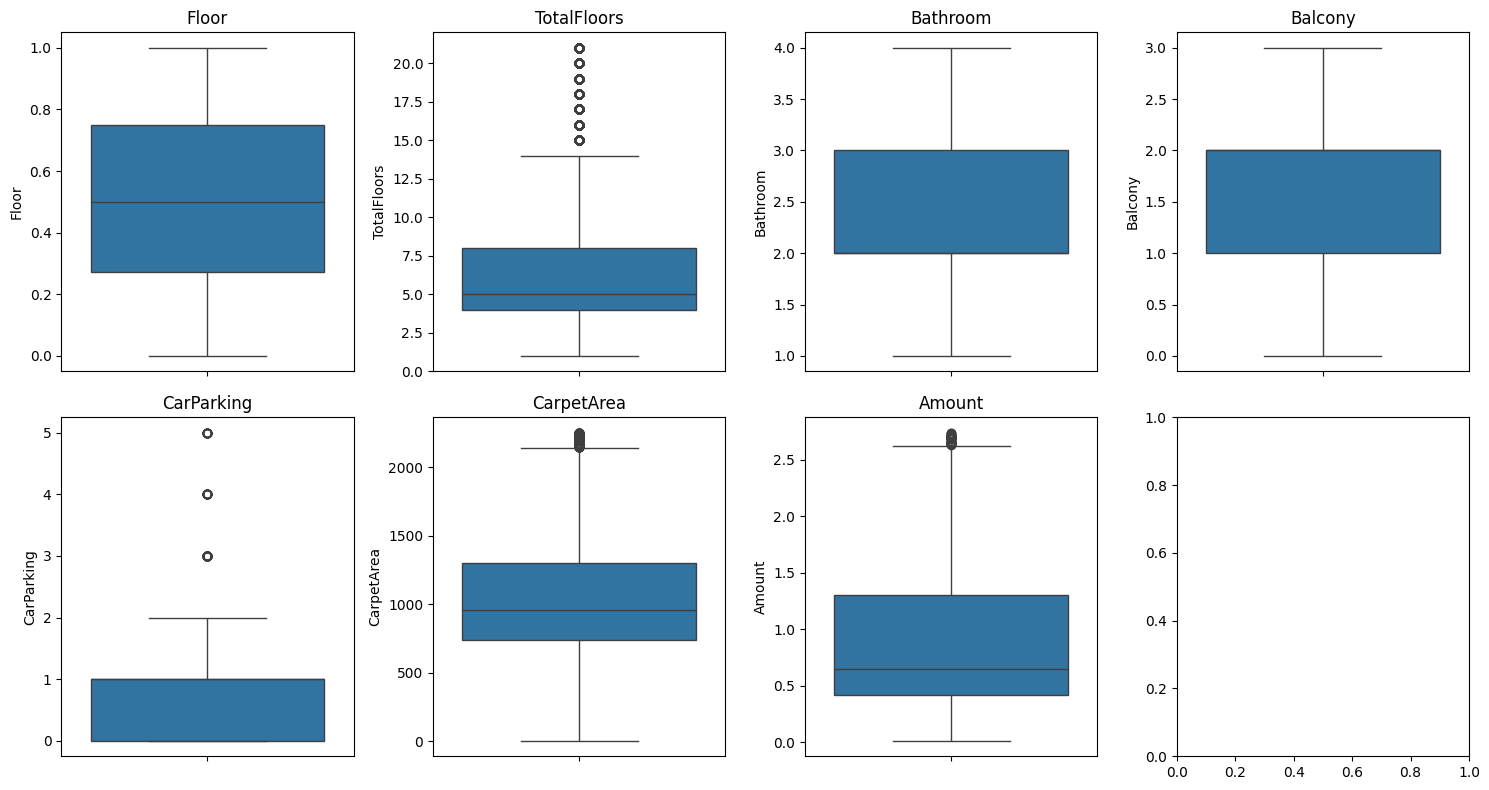

In [34]:
# rechecking outliers
num_cols = ['Floor', 'TotalFloors', 'Bathroom', 'Balcony', 'CarParking', 'CarpetArea', 'Amount']
fig, ax = plt.subplots(2, 4, figsize=(15,8))

for i, col in enumerate(num_cols, start=1):
    plt.subplot(2, 4, i)
    sns.boxplot(df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [35]:
df.shape

(77022, 17)

## **Exploratory Data Analysis**

### **Statistics**

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 77022 entries, 0 to 101267
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Location                  77022 non-null  object 
 1   Status                    77022 non-null  object 
 2   Transaction               77022 non-null  object 
 3   Ownership                 77022 non-null  object 
 4   Furnishing                77022 non-null  object 
 5   Facing                    77022 non-null  object 
 6   Overlooking_GardenPark    77022 non-null  int64  
 7   Overlooking_MainRoad      77022 non-null  int64  
 8   Overlooking_Pool          77022 non-null  int64  
 9   Overlooking_NotAvailable  77022 non-null  int64  
 10  Floor                     77022 non-null  float64
 11  TotalFloors               77022 non-null  int64  
 12  Bathroom                  77022 non-null  int64  
 13  Balcony                   77022 non-null  int64  
 14  CarParking

In [37]:
# spliting dataset
df_num = df.select_dtypes(['int64', 'float64'])
df_cat = df.select_dtypes(['object'])

In [38]:
df_num.describe()

,Overlooking_GardenPark,Overlooking_MainRoad,Overlooking_Pool,Overlooking_NotAvailable,Floor,TotalFloors,Bathroom,Balcony,CarParking,CarpetArea,Amount
count,77022.000000,77022.000000,77022.000000,77022.000000,77022.000000,77022.000000,77022.000000,77022.000000,77022.000000,77022.000000,77022.000000
mean,0.472904,0.562554,0.132949,0.298239,0.519778,6.654358,2.299031,1.704435,0.583184,983.755239,0.867300
std,0.499268,0.496075,0.339522,0.457488,0.298404,4.608789,0.711210,0.842812,0.629040,446.267551,0.590297
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.011000
25%,0.000000,0.000000,0.000000,0.000000,0.272727,4.000000,2.000000,1.000000,0.000000,740.000000,0.420000
50%,0.000000,1.000000,0.000000,0.000000,0.500000,5.000000,2.000000,2.000000,1.000000,955.000000,0.650000
75%,1.000000,1.000000,0.000000,1.000000,0.750000,8.000000,3.000000,2.000000,1.000000,1300.000000,1.300000
max,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000,4.000000,3.000000,5.000000,2253.000000,2.740000


In [39]:
df_cat.describe()

,Location,Status,Transaction,Ownership,Furnishing,Facing
count,77022,77022,77022,77022,77022,77022
unique,81,1,4,5,3,9
top,New Delhi,Ready to Move,Resale,Freehold,Semi-Furnished,East
freq,15377,77022,56772,55769,36505,30134


In [40]:
overlooking_cols = ['Overlooking_GardenPark', 'Overlooking_MainRoad', 'Overlooking_Pool', 'Overlooking_NotAvailable']

df_cat = pd.concat([df_cat, df_num[overlooking_cols]], axis=1)
df_num.drop(overlooking_cols, axis=1, inplace=True)

### **Univariate Analysis**

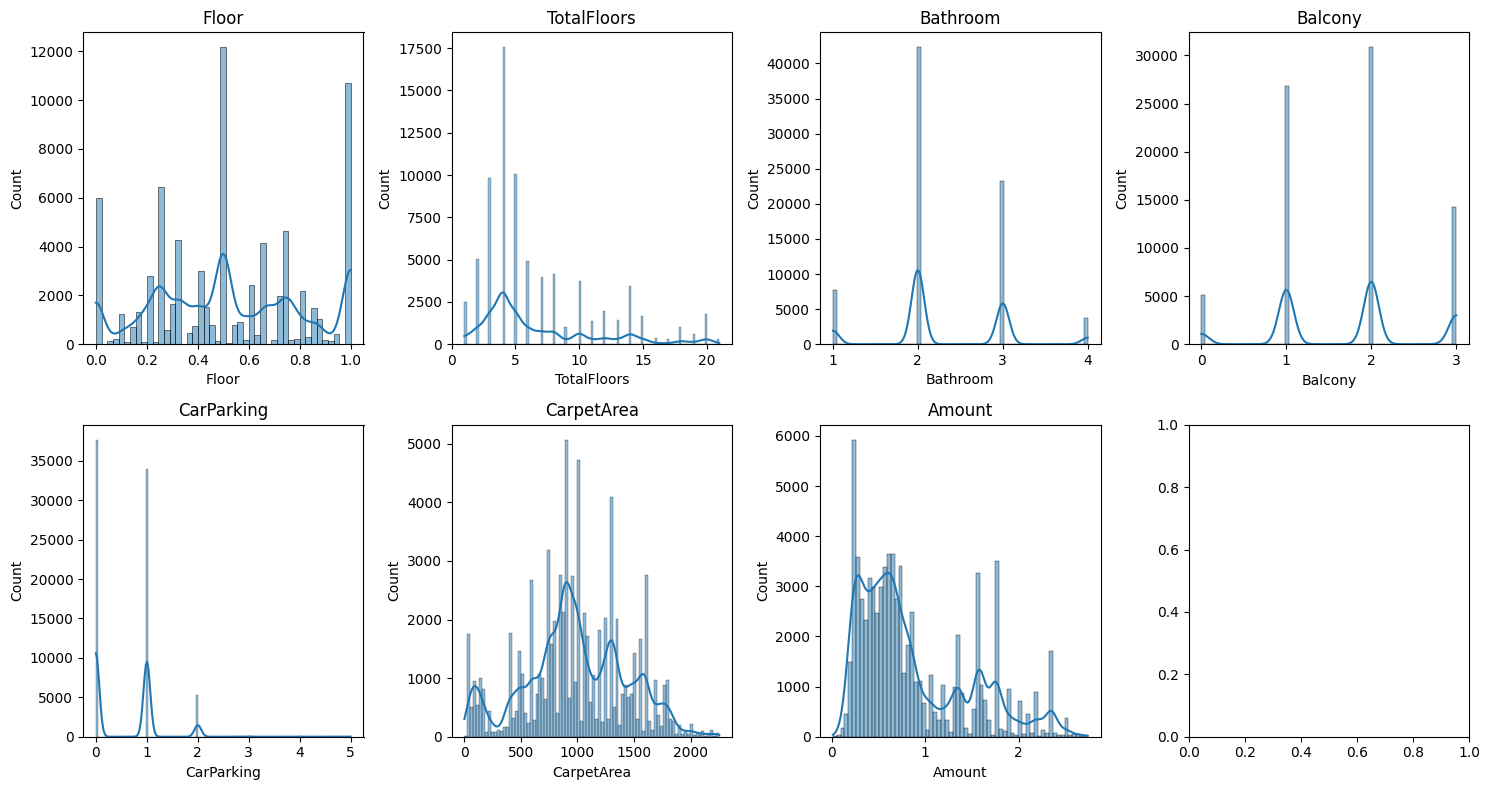

In [41]:
# analyzing numerical features
fig, ax = plt.subplots(2, 4, figsize=(15, 8))

for i, col in enumerate(df_num.columns, start=1):
    plt.subplot(2, 4, i)
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

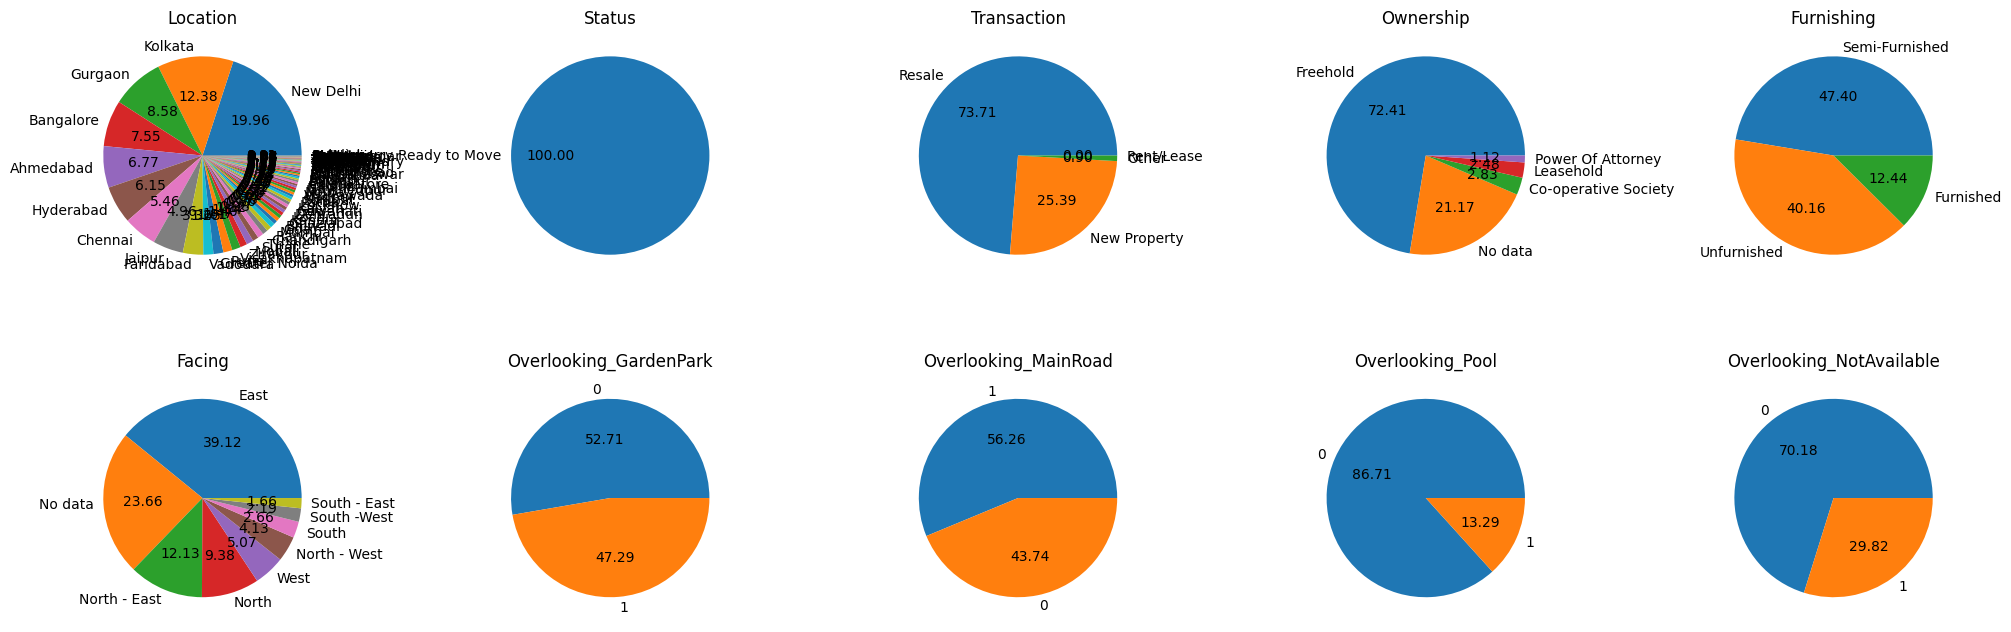

In [42]:
# analyzing categorical features
fig, ax = plt.subplots(2, 5, figsize=(20, 7))

for i, col in enumerate(df_cat.columns, start=1):
    plt.subplot(2, 5, i)
    counts = df[col].value_counts()
    plt.pie(counts, labels=counts.index, autopct='%.2f')
    plt.title(col)

plt.tight_layout()
plt.show()

### **Correlation Analysis**

<Axes: >

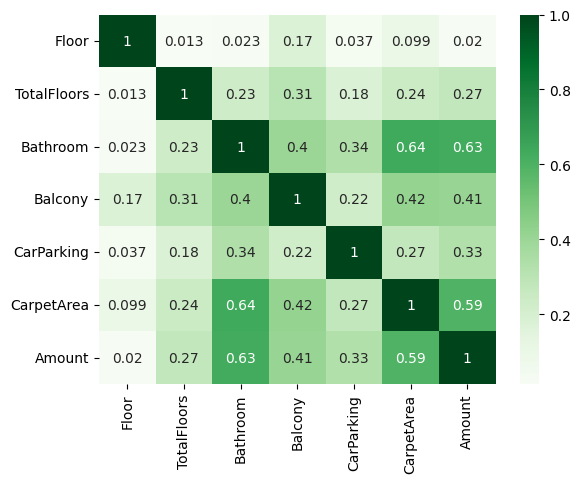

In [43]:
# for numerical columns (using heatmap)
df_num_corr = df_num.corr()
sns.heatmap(df_num_corr, annot=True, cmap='Greens')

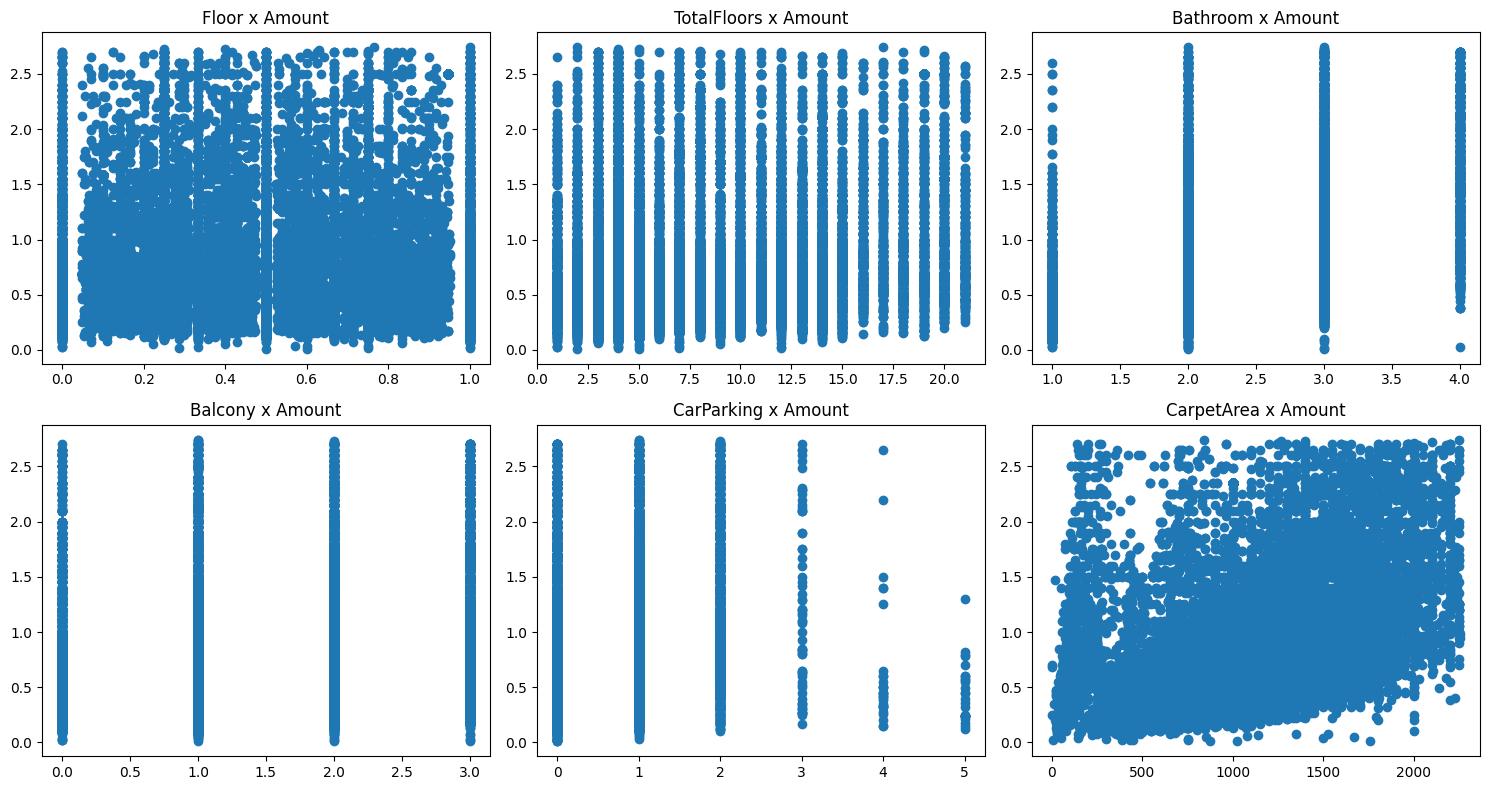

In [44]:
fig, ax = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(df_num.columns[:-1], start=1):
    plt.subplot(2, 3, i)
    plt.scatter(x=df[col], y=df['Amount'])
    plt.title(f"{col} x Amount")

plt.tight_layout()
plt.show()

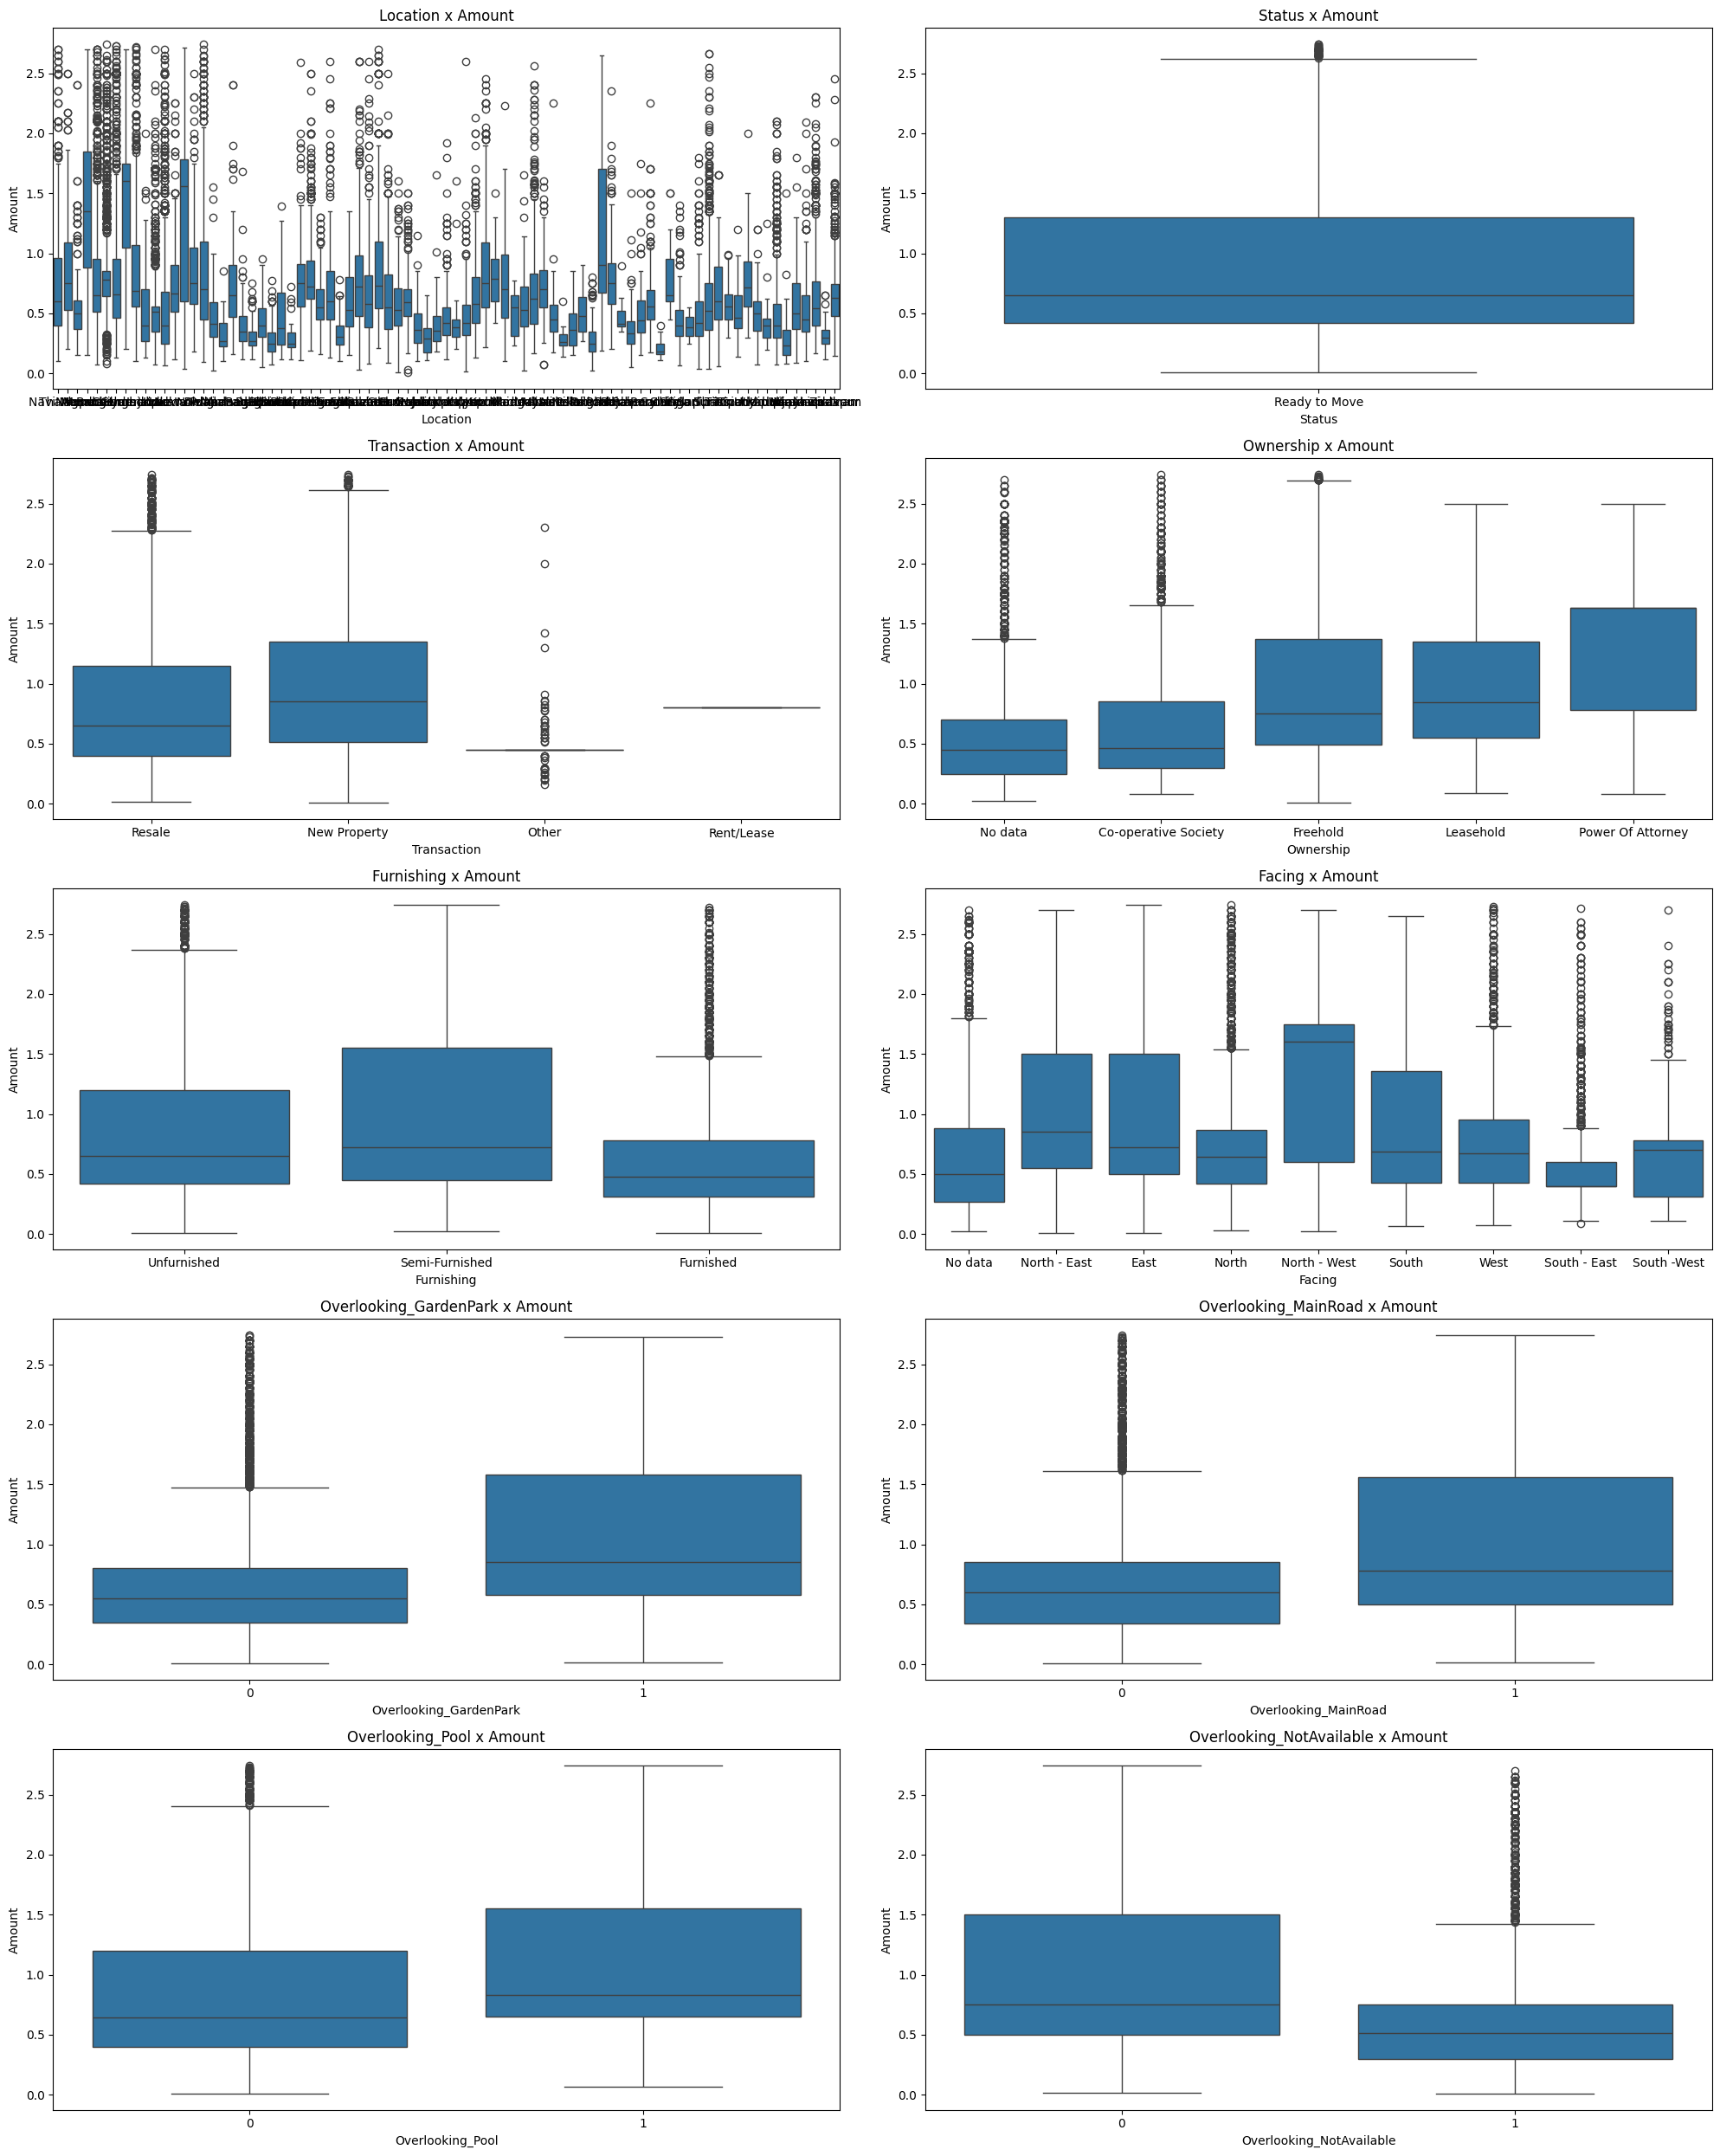

In [45]:
# for categorical columns (using boxplots)
fig, ax = plt.subplots(5, 2, figsize=(20, 25))

for i, col in enumerate(df_cat.columns, start=1):
    plt.subplot(5, 2, i)
    sns.boxplot(data=df, x=col, y='Amount')
    plt.title(f"{col} x Amount")

plt.tight_layout()
plt.show()

## **Feature Selection**
#### Based on results on EDA

In [46]:
# removing columns: Status, Overlooking_NotAvailable
df.drop(['Status', 'Overlooking_NotAvailable'], axis=1, inplace=True)
df.head()

,Location,Transaction,Ownership,Furnishing,Facing,Overlooking_GardenPark,Overlooking_MainRoad,Overlooking_Pool,Floor,TotalFloors,Bathroom,Balcony,CarParking,CarpetArea,Amount
0,Thane,Resale,No data,Unfurnished,No data,0,0,0,0.909091,11,1,2,0,500.0,0.420
3,Thane,Resale,No data,Unfurnished,No data,0,0,0,0.333333,3,1,1,0,530.0,0.250
5,Thane,Resale,No data,Unfurnished,No data,0,0,0,0.800000,5,1,0,0,550.0,0.165
7,Thane,Resale,Co-operative Society,Semi-Furnished,No data,0,1,0,0.300000,20,2,0,1,950.0,1.400
9,Thane,New Property,Freehold,Unfurnished,North - East,1,1,0,0.625000,16,2,1,1,675.0,0.900


## **Encoding Categorical Features**

In [47]:
# using ordinal ecoding for features: Transaction, Furnishing
from sklearn.preprocessing import OrdinalEncoder

transaction_order = ['Other', 'Rent/Lease', 'Resale', 'New Property']
furnishing_order = ['Unfurnished', 'Semi-Furnished', 'Furnished']

encoder = OrdinalEncoder(categories=[transaction_order])
df['Transaction'] = encoder.fit_transform(df[['Transaction']])

encoder = OrdinalEncoder(categories=[furnishing_order])
df['Furnishing'] = encoder.fit_transform(df[['Furnishing']])

In [48]:
# using label ecoding for features: Location, Ownership, Facing
from sklearn.preprocessing import LabelEncoder

columns = ['Location', 'Ownership', 'Facing']
for col in columns:
    encoder = LabelEncoder()
    df[col] = encoder.fit_transform(df[col])

In [49]:
df.head()

,Location,Transaction,Ownership,Furnishing,Facing,Overlooking_GardenPark,Overlooking_MainRoad,Overlooking_Pool,Floor,TotalFloors,Bathroom,Balcony,CarParking,CarpetArea,Amount
0,67,2.0,3,0.0,1,0,0,0,0.909091,11,1,2,0,500.0,0.420
3,67,2.0,3,0.0,1,0,0,0,0.333333,3,1,1,0,530.0,0.250
5,67,2.0,3,0.0,1,0,0,0,0.800000,5,1,0,0,550.0,0.165
7,67,2.0,0,1.0,1,0,1,0,0.300000,20,2,0,1,950.0,1.400
9,67,3.0,1,0.0,3,1,1,0,0.625000,16,2,1,1,675.0,0.900


## **Train-Test Split**

In [50]:
# split dataset into independent and dependent features
X = df.drop('Amount', axis=1)
y = df['Amount']

In [54]:
# split dataset into training and testing parts
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=10)

## **Model Training**
#### Using Random Forest

In [62]:
# training model with default parameters
from sklearn.ensemble import RandomForestRegressor
house_price_predictor = RandomForestRegressor()
house_price_predictor.fit(X_train, y_train)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


RandomForestRegressor()

In [63]:
# model evaluation
house_price_predictor.score(X_test, y_test)

0.9244490486704131